*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 09. S5 — Terminal Localisation & Causal Episode Starts
Part 1: where the effect resides relative to the raw signal (signal / next / gap bars).

Part 2: causal input at episode start — aggregate ≈ 0.

Part 3: isolated vs multi — edge asymmetry; the effect is conditional on the terminal ⇒ the correct subject for future research is predicting the end of the episode.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

from oivdc_research.forward_returns import load_forward_returns
from oivdc_research.intrabar import extract_s1_events, collect_signed_paths, impulse_metrics, hour_paths
from oivdc_research.intrabar.data5m import load_5m_data
from oivdc_research.causal import extract_raw_signals, collect_signal_paths, build_causal_events, attach_episode_length

df = load_forward_returns(CONFIG)
df5m = load_5m_data(CONFIG)
hp = hour_paths(df5m)

#### Part 1 — decomposition signal / next / gap

In [2]:
signals = extract_raw_signals(df, CONFIG)
sig_paths = collect_signal_paths(signals, hp, which="signal")
next_paths = collect_signal_paths(signals, hp, which="next")
s1 = extract_s1_events(df, CONFIG)
gap_paths = collect_signed_paths(s1, hp)

for label, p in [("signal", sig_paths), ("next", next_paths), ("gap", gap_paths)]:
    m = impulse_metrics(p)
    print(f"{label}: share_reversed={m['share_reversed']:.3f}, "
          f"n_reversed={m['n_reversed']}, mean={m['mean_total_reversal']:.5f}")

signal: share_reversed=0.000, n_reversed=0, mean=nan
next: share_reversed=0.535, n_reversed=8912, mean=0.00338
gap: share_reversed=0.661, n_reversed=8912, mean=0.00338


Expected values: signal ≈ 0% (based on the model), next ≈ 53%, gap ≈ 66%; furthermore, n_reversed(next) == n_reversed(gap) ⇒ all reversals occur in terminal signals.

Saved: reports/figures/s5/intrabar_decomposition.png


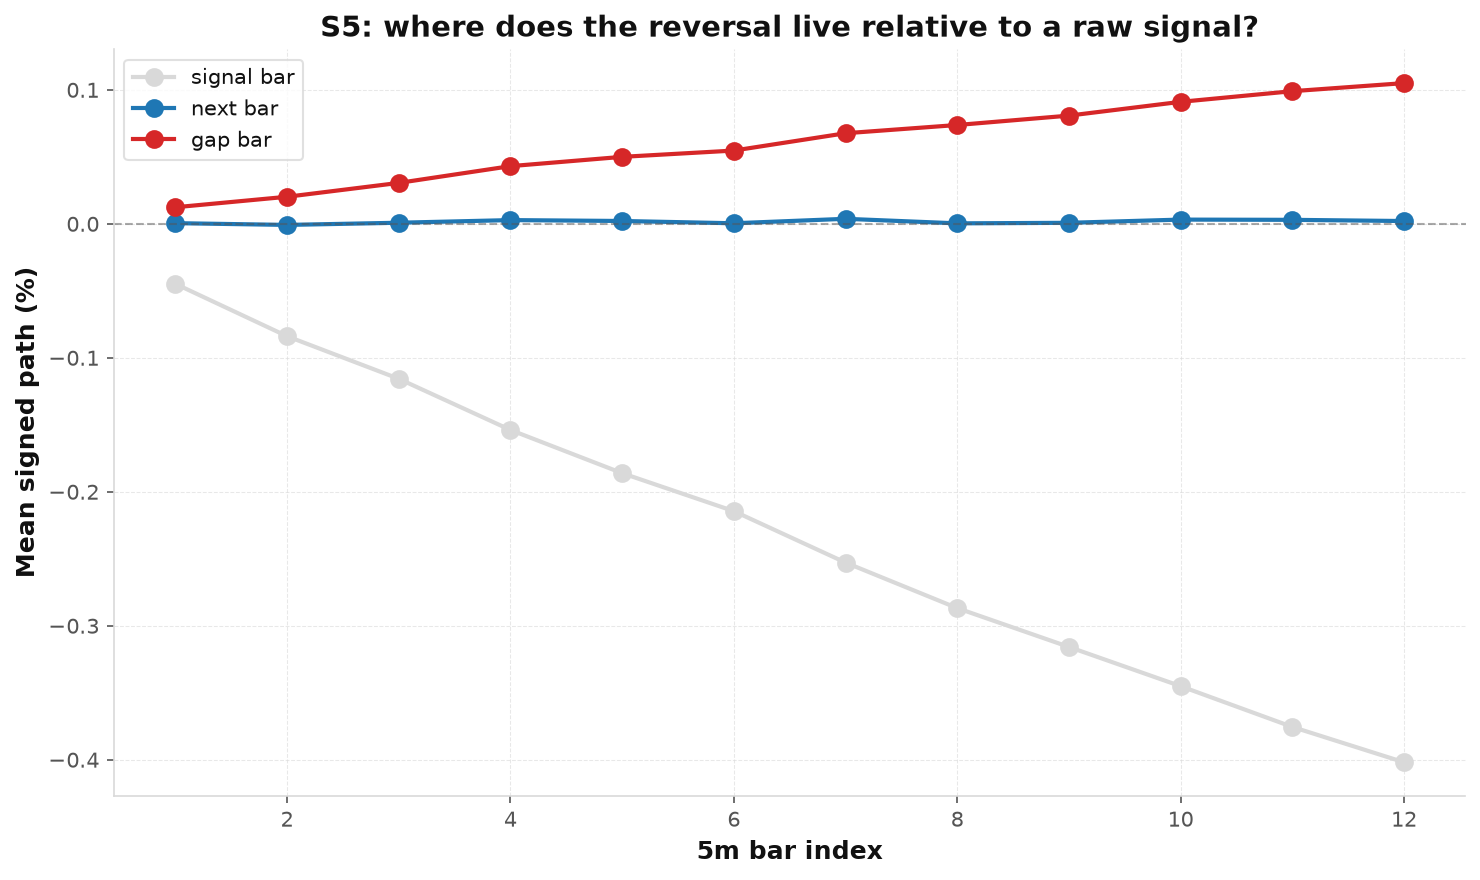

In [3]:
import matplotlib.pyplot as plt   

from oivdc_research.plotting import set_plot_style, get_palette, apply_axes_style, save_figure

set_plot_style(CONFIG.plot_theme)
pal = get_palette()

fig, ax = plt.subplots(figsize=(10, 6))
for label, p, color in [("signal bar", sig_paths, pal["grid"]),
                        ("next bar", next_paths, pal["combined"]),
                        ("gap bar", gap_paths, pal["accent"])]:
    ax.plot(range(1, 13), p.mean(axis=0) * 100, marker="o", label=label, color=color, linewidth=2)
ax.axhline(0, color=pal["text_secondary"], linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("5m bar index")
ax.set_ylabel("Mean signed path (%)")
ax.set_title("S5: where does the reversal live relative to a raw signal?")
ax.legend()
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, CONFIG.figures_dir_for("s5") / "intrabar_decomposition.png")
plt.show()

#### Part 2 — Causal entry at the start of the episode

In [4]:
HS1 = (1, 2, 3, 5, 10)
starts = build_causal_events(df, CONFIG, horizons=HS1, mode="starts")
raw = build_causal_events(df, CONFIG, horizons=HS1, mode="raw")

def summary(events, tag):
    out = []
    for h in HS1:
        x = events[f"pnl_{h}"].dropna()
        if len(x) == 0:
            continue
        out.append([tag, h, len(x), x.mean(), x.std() / np.sqrt(len(x)), (x > 0).mean()])
    return out

tab = pd.DataFrame(summary(starts, "STARTS") + summary(raw, "RAW"),
                   columns=["src", "h", "n", "mean_pnl", "se", "winrate"])
tab["t"] = tab["mean_pnl"] / tab["se"]
print(tab.pivot(index="h", columns="src", values=["mean_pnl", "winrate", "t"]).round(4))

    mean_pnl         winrate               t        
src      RAW  STARTS     RAW  STARTS     RAW  STARTS
h                                                   
1     0.0000  0.0000  0.5345  0.5267  0.4778  0.0976
2     0.0001  0.0001  0.5299  0.5236  1.5786  1.0051
3     0.0001  0.0001  0.5339  0.5273  1.3540  0.8112
5     0.0001  0.0001  0.5305  0.5242  0.5585  0.4828
10   -0.0001 -0.0001  0.5128  0.5099 -0.5406 -0.5818


#### Part 3 — isolated vs multi

In [5]:
starts2 = attach_episode_length(starts, df)

rows = []
for grp, sub in [("isolated (len=1)", starts2[starts2["isolated"]]),
                 ("multi (len>=2)", starts2[~starts2["isolated"]])]:
    x = sub["pnl_3"].dropna()
    rows.append([grp, len(x), (x > 0).mean(), x.mean()])
res = pd.DataFrame(rows, columns=["group", "n", "winrate", "mean_pnl"])
print(res.round(4))

              group      n  winrate  mean_pnl
0  isolated (len=1)  10900   0.5767     0.001
1    multi (len>=2)   2574   0.3182    -0.004


Saved: reports/figures/s5/episode_start.png


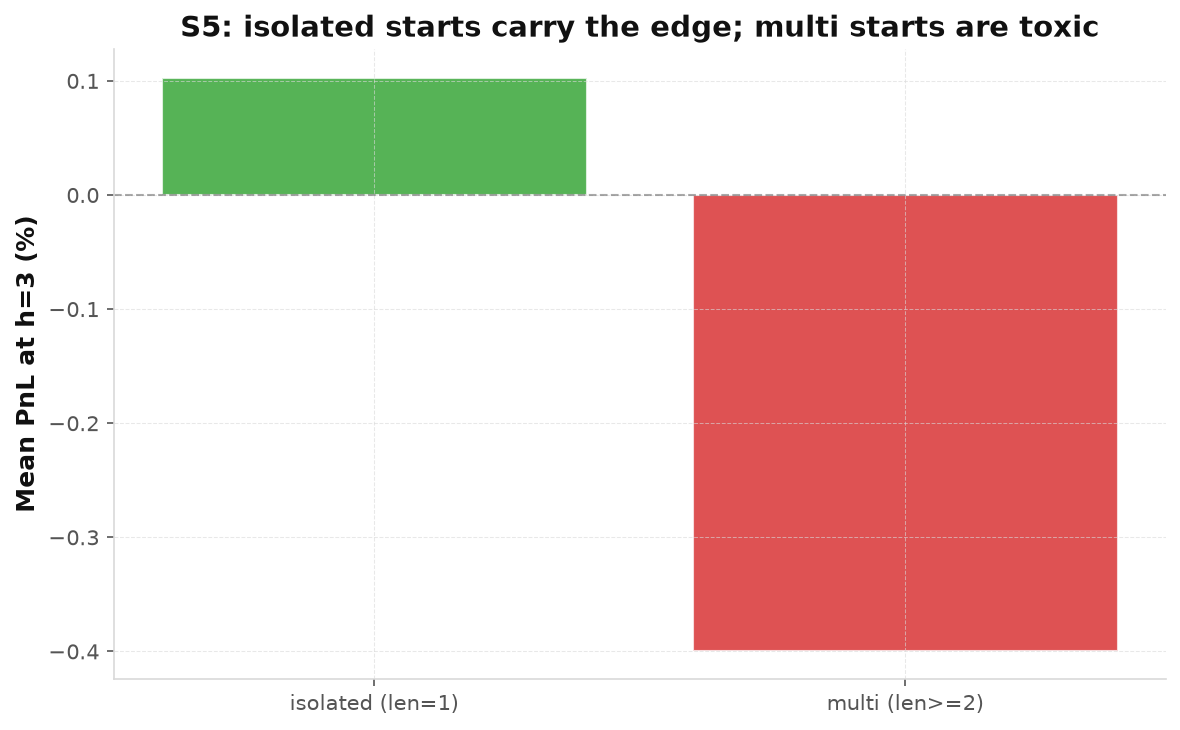

In [6]:
set_plot_style(CONFIG.plot_theme)
pal = get_palette()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(res["group"], res["mean_pnl"] * 100,
       color=[pal["long"], pal["short"]], alpha=0.8, edgecolor=pal["background"])
ax.axhline(0, color=pal["text_secondary"], linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("Mean PnL at h=3 (%)")
ax.set_title("S5: isolated starts carry the edge; multi starts are toxic")
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, CONFIG.figures_dir_for("s5") / "episode_start.png")
plt.show()

Conclusions 09: Causal STARTS ≈ 0 is a weighted mixture of ‘isolated’ (+0.1%, ~58% WR) and ‘multi’ (−0.4%, ~32% WR). The edge is real, but conditional on the terminal: without a prediction of the end of the episode, it is set to zero. Prediction of the terminal signal is the subject of a separate study (study #2, proprietary).